# ILO Public Sector Employment + IMF SAP Instrument Panel Dataset (1990–2019)

This notebook demonstrates the dataset pipeline for two panel datasets covering 68 post-1990 democratizing countries over 1990–2019:

**Dataset 1 — ILO_PSE_ILOSTAT_Democratizers_1990_2019 (701 examples, 52 countries)**  
Source: ILO ILOSTAT public sector employment data fetched via DBnomics. PSE share of total employment is computed where both numerator and denominator are available.

**Dataset 2 — Dreher_IMF_SAP_Democratizers_1990_2019 (2040 examples, 68 countries, complete coverage)**  
Source: Dreher (2006) IMF program dummies. Binary SAP dummy = 1 if country had an active IMF Standby Arrangement (SBA) or Extended Fund Facility (EFF) in that year.

The demo loads a pre-curated mini dataset (86 examples) from GitHub and walks through the pipeline's data structures, processing logic, and key statistics.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Packages NOT pre-installed on Colab (always install)
_pip('dbnomics==1.2.7')        # only needed if re-running the full data fetch
_pip('country_converter==1.3.2')
_pip('xlrd==2.0.1')            # only needed if re-loading the Dreher XLS
_pip('loguru==0.7.3')

# Core packages pre-installed on Colab; install locally to match Colab's versions
if 'google.colab' not in sys.modules:
    _pip('pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dbnomics 1.2.7 requires pandas>=2.2.3, but you have pandas 2.2.2 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import sys
from pathlib import Path

import country_converter as coco
import pandas as pd
import xlrd
from loguru import logger
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-395f4e-education-inequality-and-democratic-eros/main/round-1/dataset-2/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
import os
data = load_data()
print(f"Loaded {len(data['datasets'])} datasets")
for ds in data['datasets']:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")

Loaded 2 datasets
  ILO_PSE_ILOSTAT_Democratizers_1990_2019: 26 examples
  Dreher_IMF_SAP_Democratizers_1990_2019: 60 examples


## Config

Parameters controlling the demo display. These do not affect how the pipeline processes data — the pipeline is a pure data extraction/transformation step with no tunable ML parameters. Adjust these to explore different slices of the panel.

In [5]:
# Countries present in the mini demo data
PSE_COUNTRIES = ['POL', 'GHA']           # countries with ILO PSE time series
SAP_COUNTRIES = ['ALB', 'POL', 'KEN', 'ARG']  # countries in Dreher SAP panel

# Preview rows shown per dataset in the table display
SHOW_N_EXAMPLES = 5

# Full list of 68 democratizers used in the production pipeline
POST90_DEMOCRATIZERS = [
    "ALB", "ARM", "AZE", "BIH", "BGR", "HRV", "CZE", "EST", "GEO", "HUN",
    "KAZ", "KGZ", "LVA", "LTU", "MDA", "MNE", "MKD", "POL", "ROU", "RUS",
    "SRB", "SVK", "SVN", "TJK", "TKM", "UKR", "UZB",
    "BEN", "BWA", "CPV", "GHA", "KEN", "LSO", "MWI", "MLI", "MOZ", "NAM",
    "NER", "NGA", "SEN", "SLE", "TZA", "ZMB", "ZWE",
    "ECU", "MEX", "PRY", "PER", "SLV", "GTM", "HND", "NIC", "DOM",
    "BOL", "CHL", "ARG", "BRA", "COL", "URY", "VEN",
    "MNG", "IDN", "PHL", "THA", "TWN", "KOR",
    "TUN", "MAR",
]

YEARS = list(range(1990, 2020))

## Dataset 1: ILO Public Sector Employment

The pipeline fetches ILO PSE_TPSE_GOV_NB (public sector employment in thousands) and EMP_TEMP_SEX_ECO_NB (total employment) from DBnomics, filters to the total public sector level (`GOV_LVL_PSE`) and total sex (`SEX_T`), deduplicates by averaging across survey sources per country-year, and computes PSE share of total employment.

The pre-computed output uses the `exp_sel_data_out` schema: each example has an `input` field (country + year), an `output` field (the measurement), and metadata fields.

In [6]:
# Extract PSE examples from the loaded mini data
pse_examples = data['datasets'][0]['examples']

print(f"ILO PSE dataset: {len(pse_examples)} examples")
print(f"Countries: {sorted(set(e['metadata_iso3'] for e in pse_examples))}")
print(f"Year range: {min(e['metadata_year'] for e in pse_examples)}–{max(e['metadata_year'] for e in pse_examples)}")
print()
print(f"First {SHOW_N_EXAMPLES} examples:")
for ex in pse_examples[:SHOW_N_EXAMPLES]:
    print(f"  input:  {ex['input']}")
    print(f"  output: {ex['output']}")
    print()

ILO PSE dataset: 26 examples
Countries: ['POL']
Year range: 1990–2019

First 5 examples:
  input:  Country: POL, Year: 1990
  output: public_sector_employment: 8927.3 thousand workers, pse_share_of_total_employment: NA

  input:  Country: POL, Year: 1995
  output: public_sector_employment: 5554.3 thousand workers, pse_share_of_total_employment: 37.55%

  input:  Country: POL, Year: 1996
  output: public_sector_employment: 5341.3 thousand workers, pse_share_of_total_employment: 35.68%

  input:  Country: POL, Year: 1997
  output: public_sector_employment: 5426.5 thousand workers, pse_share_of_total_employment: 35.77%

  input:  Country: POL, Year: 1998
  output: public_sector_employment: 5017.3 thousand workers, pse_share_of_total_employment: 32.66%



### Parsing PSE Output Fields

The `output` string encodes two measurements: PSE in thousands of workers and PSE share of total employment. We parse these for analysis and visualization.

In [7]:
import re

def parse_pse_output(output_str):
    """Extract pse_thousands and pse_share_pct from the output string."""
    m_pse = re.search(r'public_sector_employment: ([\d.]+) thousand', output_str)
    m_share = re.search(r'pse_share_of_total_employment: ([\d.]+)%', output_str)
    pse_thousands = float(m_pse.group(1)) if m_pse else None
    pse_share_pct = float(m_share.group(1)) if m_share else None
    return pse_thousands, pse_share_pct

# Build a DataFrame from the parsed examples
rows = []
for ex in pse_examples:
    pse_k, pse_share = parse_pse_output(ex['output'])
    rows.append({
        'iso3': ex['metadata_iso3'],
        'year': ex['metadata_year'],
        'pse_thousands': pse_k,
        'pse_share_pct': pse_share,
    })

pse_df = pd.DataFrame(rows)
print(pse_df.head(SHOW_N_EXAMPLES).to_string(index=False))
print(f"\nSummary stats:")
print(pse_df[['pse_thousands', 'pse_share_pct']].describe().round(2).to_string())

iso3  year  pse_thousands  pse_share_pct
 POL  1990         8927.3            NaN
 POL  1995         5554.3          37.55
 POL  1996         5341.3          35.68
 POL  1997         5426.5          35.77
 POL  1998         5017.3          32.66

Summary stats:
       pse_thousands  pse_share_pct
count          26.00          25.00
mean         4112.58          25.93
std          1201.51           5.28
min          3343.60          20.53
25%          3424.30          21.68
50%          3628.25          23.75
75%          4245.50          28.57
max          8927.30          37.55


## Dataset 2: Dreher (2006) IMF SAP Dummies

The pipeline reads the Dreher (2006) XLS dataset (222 countries, 1970–2019) and extracts SBA and EFF program dummies for each country-year. `sap_active = 1` if the country had either program active that year. PRGF/ECF programs are excluded as they protect social spending. The panel is complete: all 68 democratizers × 30 years = 2040 rows, with 190 SAP-active observations (9.3%).

In [8]:
# Extract SAP examples from the loaded mini data
sap_examples = data['datasets'][1]['examples']

sap_active_count = sum(1 for e in sap_examples if 'imf_sap_active: 1' in e['output'])
print(f"Dreher SAP dataset: {len(sap_examples)} examples")
print(f"Countries: {sorted(set(e['metadata_iso3'] for e in sap_examples))}")
print(f"SAP-active observations: {sap_active_count} ({sap_active_count/len(sap_examples)*100:.1f}%)")
print()
print(f"First {SHOW_N_EXAMPLES} examples (Albania — shows 0→1 transition):")
for ex in sap_examples[:SHOW_N_EXAMPLES]:
    print(f"  input:  {ex['input']}")
    print(f"  output: {ex['output']}")
    print()

Dreher SAP dataset: 60 examples
Countries: ['ALB', 'ARG', 'KEN', 'POL']
SAP-active observations: 10 (16.7%)

First 5 examples (Albania — shows 0→1 transition):
  input:  Country: ALB, Year: 1990
  output: imf_sap_active: 0 [IMF Structural Adjustment Program not active — SBA or EFF, source: Dreher 2006]

  input:  Country: ALB, Year: 1992
  output: imf_sap_active: 1 [IMF Structural Adjustment Program active — SBA or EFF, source: Dreher 2006]

  input:  Country: ALB, Year: 1994
  output: imf_sap_active: 0 [IMF Structural Adjustment Program not active — SBA or EFF, source: Dreher 2006]

  input:  Country: ALB, Year: 1996
  output: imf_sap_active: 0 [IMF Structural Adjustment Program not active — SBA or EFF, source: Dreher 2006]

  input:  Country: ALB, Year: 1998
  output: imf_sap_active: 0 [IMF Structural Adjustment Program not active — SBA or EFF, source: Dreher 2006]



### Building the SAP Panel

The SAP output is a binary dummy. We parse it into a DataFrame for cross-country comparison.

In [9]:
sap_rows = []
for ex in sap_examples:
    m = re.search(r'imf_sap_active: (\d)', ex['output'])
    sap_rows.append({
        'iso3': ex['metadata_iso3'],
        'year': ex['metadata_year'],
        'sap_active': int(m.group(1)) if m else 0,
    })

sap_df = pd.DataFrame(sap_rows)

# Pivot to show the program timeline per country
pivot = sap_df.pivot(index='iso3', columns='year', values='sap_active')
print("SAP active (1=yes) by country-year (demo subset):")
print(pivot.to_string())

SAP active (1=yes) by country-year (demo subset):
year  1990  1992  1994  1996  1998  2000  2002  2004  2006  2008  2010  2012  2014  2016  2018
iso3                                                                                          
ALB      0     1     0     0     0     0     0     0     1     0     0     0     1     0     0
ARG      0     1     0     1     1     1     0     0     0     0     0     0     0     0     1
KEN      0     0     0     0     0     0     0     0     0     0     0     0     0     0     0
POL      1     0     1     0     0     0     0     0     0     0     0     0     0     0     0


## Results Visualization

Two panels:
1. **PSE share over time** — public sector employment as % of total employment for each country in the mini dataset
2. **SAP timeline heatmap** — binary SAP program activity by country and year

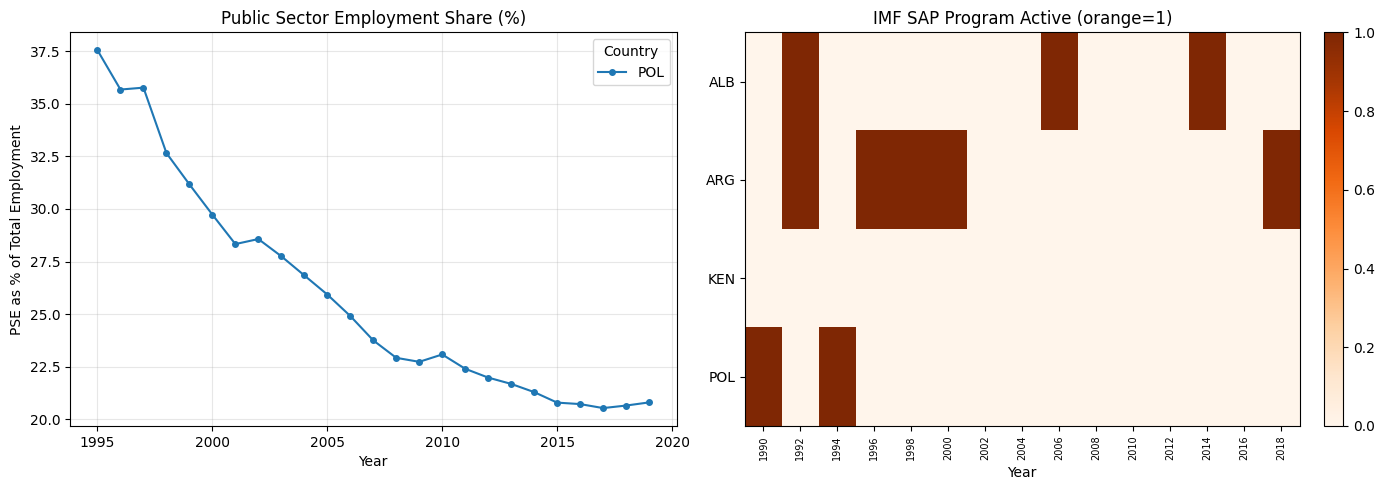

Saved: results_visualization.png

=== Dataset Summary ===
Dataset                                       Examples  Countries
-----------------------------------------------------------------
ILO_PSE_ILOSTAT_Democratizers_1990_2019             26          1
Dreher_IMF_SAP_Democratizers_1990_2019              60          4

Total post-1990 democratizers in full pipeline: 68
Full year range: 1990–2019 (30 years)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel 1: PSE share over time ---
ax1 = axes[0]
for iso3, grp in pse_df.groupby('iso3'):
    grp_sorted = grp.sort_values('year')
    ax1.plot(grp_sorted['year'], grp_sorted['pse_share_pct'], marker='o', markersize=4, label=iso3)
ax1.set_title('Public Sector Employment Share (%)', fontsize=12)
ax1.set_xlabel('Year')
ax1.set_ylabel('PSE as % of Total Employment')
ax1.legend(title='Country')
ax1.grid(alpha=0.3)
ax1.xaxis.set_major_locator(mticker.MultipleLocator(5))

# --- Panel 2: SAP heatmap ---
ax2 = axes[1]
heatmap_data = sap_df.pivot(index='iso3', columns='year', values='sap_active').fillna(0)
im = ax2.imshow(heatmap_data.values, aspect='auto', cmap='Oranges', vmin=0, vmax=1)
ax2.set_xticks(range(len(heatmap_data.columns)))
ax2.set_xticklabels(heatmap_data.columns, rotation=90, fontsize=7)
ax2.set_yticks(range(len(heatmap_data.index)))
ax2.set_yticklabels(heatmap_data.index)
ax2.set_title('IMF SAP Program Active (orange=1)', fontsize=12)
ax2.set_xlabel('Year')
fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('results_visualization.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: results_visualization.png")

# --- Summary table ---
print("\n=== Dataset Summary ===")
print(f"{'Dataset':<45} {'Examples':>8} {'Countries':>10}")
print("-" * 65)
for ds in data['datasets']:
    n_countries = len(set(e['metadata_iso3'] for e in ds['examples']))
    print(f"{ds['dataset']:<45} {len(ds['examples']):>8} {n_countries:>10}")
print(f"\nTotal post-1990 democratizers in full pipeline: {len(POST90_DEMOCRATIZERS)}")
print(f"Full year range: {YEARS[0]}–{YEARS[-1]} ({len(YEARS)} years)")